In [64]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kanchandalal123/kaya-delay-prediction-data-v3/delivery_delays (2).csv
/kaggle/input/datasets/kanchandalal123/kaya-delay-prediction-data-v2/delivery_delays (1).csv
/kaggle/input/datasets/kanchandalal123/delay-prediction-model-synthetic-data/delivery_delays.csv


In [65]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import shap

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.calibration import calibration_curve

import xgboost as xgb
import lightgbm as lgb

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [66]:
df = pd.read_csv("/kaggle/input/datasets/kanchandalal123/kaya-delay-prediction-data-v3/delivery_delays (2).csv")

print(df.shape)

df.head()

(5000, 36)


,order_id,order_date,month,day_of_week,quarter,is_festival_period,material_type,supplier_tier,origin_state,destination_state,...,traffic_status,waiting_time,inventory_level,asset_utilization,demand_forecast,order_value_inr,road_quality,supplier_capacity,fuel_price_index,driver_experience
0,ORD-00001,2023-08-17,8,3,3,1,TMT Steel,Tier 3 (Local Supplier),Rajasthan,Gujarat,...,Heavy,53,221,62.0,430,1320600.0,0.73,73,104.12,21
1,ORD-00002,2023-07-29,7,5,3,0,Plywood,Tier 3 (Local Supplier),Haryana,Madhya Pradesh,...,Detour,56,956,68.1,158,24035.0,0.63,77,101.78,12
2,ORD-00003,2023-03-07,3,1,1,0,TMT Steel,Tier 1 (Large Manufacturer),Gujarat,Gujarat,...,Moderate,37,876,55.7,997,1624400.0,0.82,77,99.76,15
3,ORD-00004,2025-05-09,5,4,2,0,Coarse Aggregate,Tier 2 (Regional Distributor),Telangana,Rajasthan,...,Detour,56,205,80.5,576,76680.0,0.68,75,90.23,12
4,ORD-00005,2023-11-23,11,3,4,0,Paint,Tier 2 (Regional Distributor),Uttar Pradesh,Rajasthan,...,Moderate,50,287,79.4,140,54880.0,0.61,64,84.99,8


In [67]:
print("="*60)
print("Dataset Shape")
print(df.shape)

print("\n")

print("="*60)
print("Columns")
print(df.columns)

print("\n")

print("="*60)
print("Missing Values")
print(df.isnull().sum())

print("\n")

print("="*60)
print("Duplicate Rows")
print(df.duplicated().sum())

Dataset Shape
(5000, 36)


Columns
Index(['order_id', 'order_date', 'month', 'day_of_week', 'quarter',
       'is_festival_period', 'material_type', 'supplier_tier', 'origin_state',
       'destination_state', 'distance_km', 'order_quantity',
       'promised_lead_days', 'monsoon_intensity', 'monsoon_sensitivity',
       'dest_logistics_score', 'orig_logistics_score', 'dest_monsoon_severity',
       'supplier_reliability', 'past_delay_rate', 'delay_probability',
       'is_delayed', 'actual_delay_days', 'vehicle_type', 'temperature',
       'humidity', 'traffic_status', 'waiting_time', 'inventory_level',
       'asset_utilization', 'demand_forecast', 'order_value_inr',
       'road_quality', 'supplier_capacity', 'fuel_price_index',
       'driver_experience'],
      dtype='object')


Missing Values
order_id                 0
order_date               0
month                    0
day_of_week              0
quarter                  0
is_festival_period       0
material_type            0
s

In [68]:
df.head()

,order_id,order_date,month,day_of_week,quarter,is_festival_period,material_type,supplier_tier,origin_state,destination_state,...,traffic_status,waiting_time,inventory_level,asset_utilization,demand_forecast,order_value_inr,road_quality,supplier_capacity,fuel_price_index,driver_experience
0,ORD-00001,2023-08-17,8,3,3,1,TMT Steel,Tier 3 (Local Supplier),Rajasthan,Gujarat,...,Heavy,53,221,62.0,430,1320600.0,0.73,73,104.12,21
1,ORD-00002,2023-07-29,7,5,3,0,Plywood,Tier 3 (Local Supplier),Haryana,Madhya Pradesh,...,Detour,56,956,68.1,158,24035.0,0.63,77,101.78,12
2,ORD-00003,2023-03-07,3,1,1,0,TMT Steel,Tier 1 (Large Manufacturer),Gujarat,Gujarat,...,Moderate,37,876,55.7,997,1624400.0,0.82,77,99.76,15
3,ORD-00004,2025-05-09,5,4,2,0,Coarse Aggregate,Tier 2 (Regional Distributor),Telangana,Rajasthan,...,Detour,56,205,80.5,576,76680.0,0.68,75,90.23,12
4,ORD-00005,2023-11-23,11,3,4,0,Paint,Tier 2 (Regional Distributor),Uttar Pradesh,Rajasthan,...,Moderate,50,287,79.4,140,54880.0,0.61,64,84.99,8


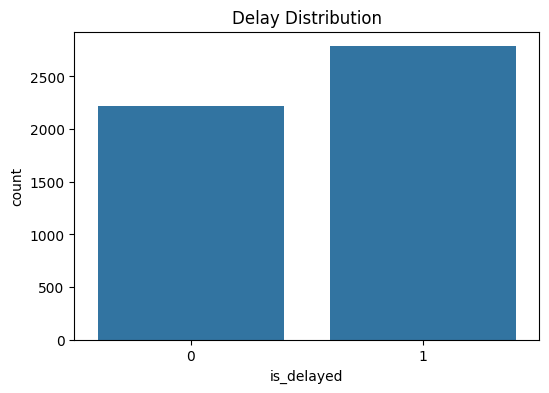

is_delayed
1    55.7
0    44.3
Name: proportion, dtype: float64


In [69]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="is_delayed",
    data=df
)

plt.title("Delay Distribution")

plt.show()

print(df["is_delayed"].value_counts(normalize=True)*100)

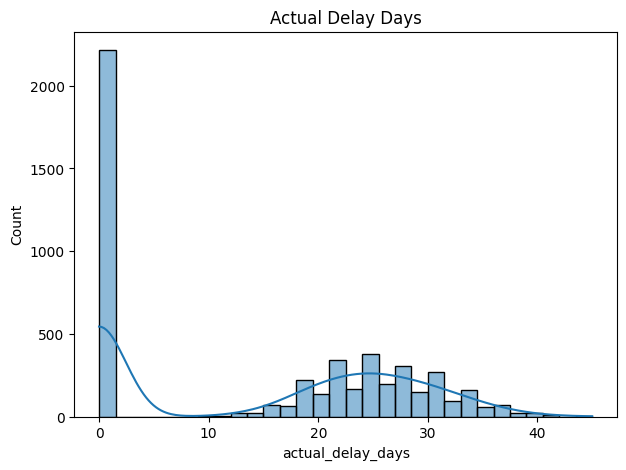

In [70]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["actual_delay_days"],
    bins=30,
    kde=True
)

plt.title("Actual Delay Days")

plt.show()

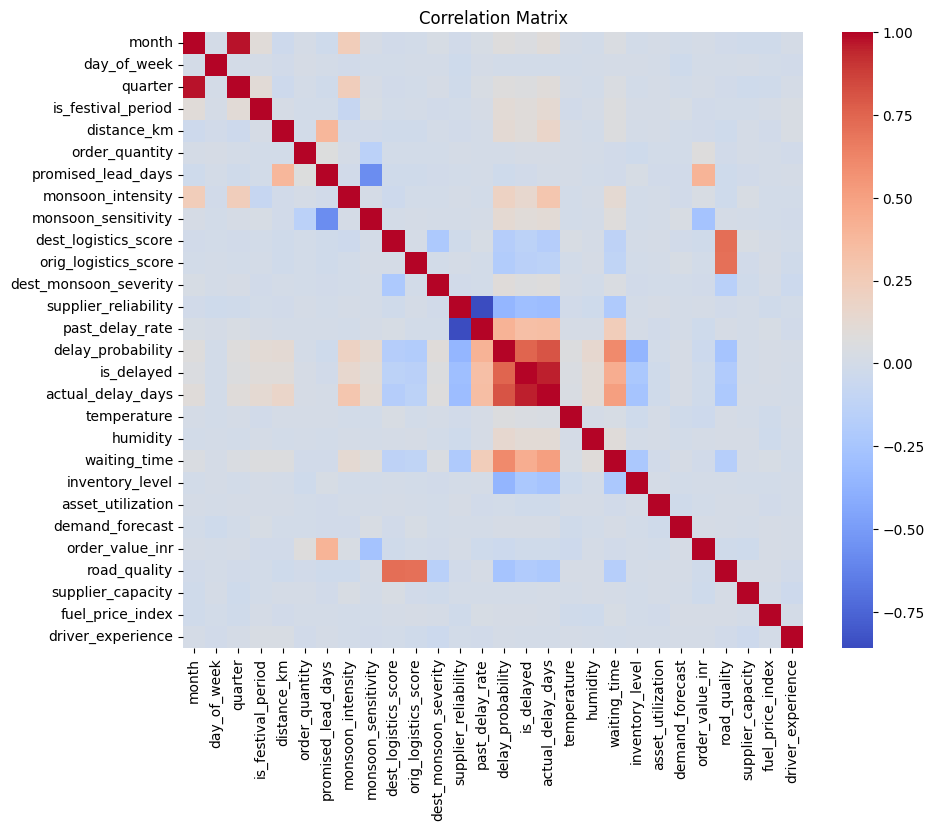

In [71]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [72]:
# High temperature
df["High_Temperature"] = (
    df["temperature"] >= 35
).astype(int)

# High humidity
df["High_Humidity"] = (
    df["humidity"] >= 75
).astype(int)

# Heavy traffic
df["High_Traffic"] = (
    df["traffic_status"] == "Heavy"
).astype(int)

# Long waiting time
df["Long_Wait"] = (
    df["waiting_time"] >= 30
).astype(int)

# Low inventory
df["Low_Inventory"] = (
    df["inventory_level"] <= 250
).astype(int)

# Long distance shipment
df["Long_Distance"] = (
    df["distance_km"] >= 800
).astype(int)

# High order value
df["High_Order_Value"] = (
    df["order_value_inr"] >
    df["order_value_inr"].median()
).astype(int)

# Poor road quality
df["Poor_Road"] = (
    df["road_quality"] < 0.55
).astype(int)

# Poor logistics
df["Poor_Logistics"] = (
    df["dest_logistics_score"] < 0.55
).astype(int)

# Environmental Risk Score
df["Environmental_Risk"] = (
      df["High_Temperature"]
    + df["High_Humidity"]
    + (df["monsoon_intensity"] > 0.60).astype(int)
)

print("Feature Engineering Completed")

Feature Engineering Completed


In [73]:
new_features = [

    "High_Temperature",
    "High_Humidity",
    "High_Traffic",
    "Long_Wait",
    "Low_Inventory",
    "Long_Distance",
    "High_Order_Value",
    "Poor_Road",
    "Poor_Logistics",
    "Environmental_Risk"

]

df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
High_Temperature,5000.0,0.2308,0.421387,0.0,0.0,0.0,0.0,1.0
High_Humidity,5000.0,0.3280,0.469532,0.0,0.0,0.0,1.0,1.0
High_Traffic,5000.0,0.0620,0.241180,0.0,0.0,0.0,0.0,1.0
Long_Wait,5000.0,0.9612,0.193137,0.0,1.0,1.0,1.0,1.0
Low_Inventory,5000.0,0.1704,0.376021,0.0,0.0,0.0,0.0,1.0
Long_Distance,5000.0,0.5752,0.494362,0.0,0.0,1.0,1.0,1.0
High_Order_Value,5000.0,0.5000,0.500050,0.0,0.0,0.5,1.0,1.0
Poor_Road,5000.0,0.1252,0.330979,0.0,0.0,0.0,0.0,1.0
Poor_Logistics,5000.0,0.2062,0.404616,0.0,0.0,0.0,0.0,1.0
Environmental_Risk,5000.0,0.8132,0.778734,0.0,0.0,1.0,1.0,3.0


In [74]:
encoders = {}

categorical_columns = [

    "material_type",
    "supplier_tier",
    "origin_state",
    "destination_state",
    "vehicle_type",
    "traffic_status"

]

for col in categorical_columns:

    le = LabelEncoder()

    df[col + "_enc"] = le.fit_transform(df[col])

    encoders[col] = le

print("Encoding Completed")

Encoding Completed


In [75]:
FEATURES = [

    "month",
    "day_of_week",
    "quarter",

    "is_festival_period",

    "material_type_enc",
    "supplier_tier_enc",
    "origin_state_enc",
    "destination_state_enc",

    "vehicle_type_enc",
    "traffic_status_enc",

    "distance_km",
    "order_quantity",
    "promised_lead_days",

    "temperature",
    "humidity",

    "waiting_time",
    "inventory_level",

    "asset_utilization",
    "demand_forecast",

    "order_value_inr",

    "road_quality",

    "supplier_reliability",

    "past_delay_rate",

    "monsoon_intensity",
    "monsoon_sensitivity",

    "dest_logistics_score",
    "orig_logistics_score",
    "dest_monsoon_severity",

    "High_Temperature",
    "High_Humidity",
    "High_Traffic",
    "Long_Wait",
    "Low_Inventory",
    "Long_Distance",
    "High_Order_Value",
    "Poor_Road",
    "Poor_Logistics",
    "Environmental_Risk"

]

X = df[FEATURES]

y_clf = df["is_delayed"]

y_reg = df["actual_delay_days"]

print("Feature Matrix :", X.shape)
print("Classification Target :", y_clf.shape)
print("Regression Target :", y_reg.shape)

Feature Matrix : (5000, 38)
Classification Target : (5000,)
Regression Target : (5000,)


In [76]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(

    X,
    y_clf,

    test_size=0.20,

    random_state=42,

    stratify=y_clf

)

delayed_df = df[df["is_delayed"] == 1]

X_reg = delayed_df[FEATURES]

y_reg = delayed_df["actual_delay_days"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(

    X_reg,
    y_reg,

    test_size=0.20,

    random_state=42

)

print("Classifier Train :", X_train_clf.shape)
print("Classifier Test :", X_test_clf.shape)

print()

print("Regressor Train :", X_train_reg.shape)
print("Regressor Test :", X_test_reg.shape)

Classifier Train : (4000, 38)
Classifier Test : (1000, 38)

Regressor Train : (2228, 38)
Regressor Test : (557, 38)


In [77]:
clf = xgb.XGBClassifier(

    n_estimators=500,

    max_depth=7,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric="logloss",

    random_state=42,

    verbosity=0
)

clf.fit(
    X_train_clf,
    y_train_clf
)

print("Delay Classifier Trained Successfully")

Delay Classifier Trained Successfully


In [78]:
pred_clf = clf.predict(X_test_clf)

prob_clf = clf.predict_proba(X_test_clf)[:,1]

In [79]:
print("="*50)
print("Accuracy :", accuracy_score(y_test_clf,pred_clf))

print("="*50)
print("Precision :", precision_score(y_test_clf,pred_clf))

print("="*50)
print("Recall :", recall_score(y_test_clf,pred_clf))

print("="*50)
print("F1 Score :", f1_score(y_test_clf,pred_clf))

print("="*50)
print("ROC AUC :", roc_auc_score(y_test_clf,prob_clf))

Accuracy : 0.869
Precision : 0.9243027888446215
Recall : 0.8330341113105925
F1 Score : 0.8762983947119924
ROC AUC : 0.9226183480512744


In [80]:
print(
    classification_report(
        y_test_clf,
        pred_clf,
        target_names=[
            "On Time",
            "Delayed"
        ]
    )
)

              precision    recall  f1-score   support

     On Time       0.81      0.91      0.86       443
     Delayed       0.92      0.83      0.88       557

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.88      0.87      0.87      1000



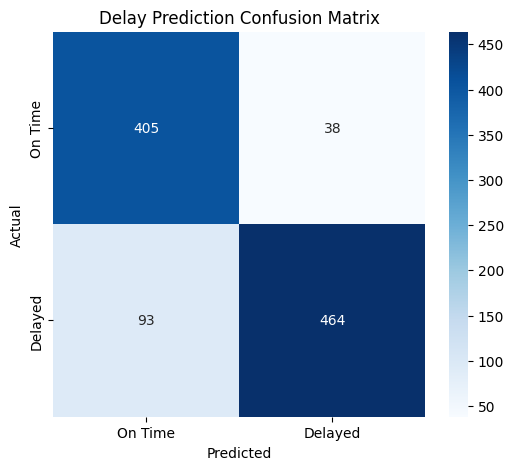

In [81]:
cm = confusion_matrix(
    y_test_clf,
    pred_clf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["On Time","Delayed"],
    yticklabels=["On Time","Delayed"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Delay Prediction Confusion Matrix")

plt.show()

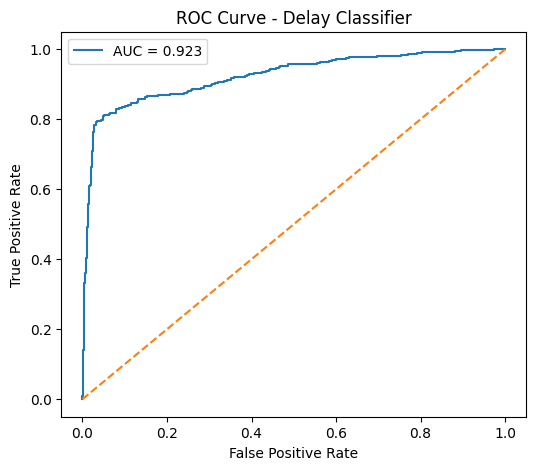

In [82]:
fpr, tpr, thresholds = roc_curve(
    y_test_clf,
    prob_clf
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test_clf,prob_clf):.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Delay Classifier")

plt.legend()

plt.show()

In [83]:
reg = lgb.LGBMRegressor(

    objective="regression",

    n_estimators=500,

    learning_rate=0.05,

    max_depth=7,

    random_state=42,

    verbose=-1
)

reg.fit(
    X_train_reg,
    y_train_reg
)

print("Delay Regressor Trained Successfully")

Delay Regressor Trained Successfully


In [84]:
pred_reg = reg.predict(X_test_reg)

In [85]:
mae = mean_absolute_error(
    y_test_reg,
    pred_reg
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        pred_reg
    )
)

r2 = r2_score(
    y_test_reg,
    pred_reg
)

print("="*50)
print("MAE :", round(mae,2))

print("="*50)
print("RMSE :", round(rmse,2))

print("="*50)
print("R² :", round(r2,3))

MAE : 1.86
RMSE : 2.33
R² : 0.847


In [86]:
reg_lo = lgb.LGBMRegressor(

    objective="quantile",

    alpha=0.10,

    n_estimators=400,

    learning_rate=0.05,

    max_depth=7,

    random_state=42,

    verbose=-1
)

reg_lo.fit(
    X_train_reg,
    y_train_reg
)

print("Lower Quantile Model Ready")

Lower Quantile Model Ready


In [87]:
reg_hi = lgb.LGBMRegressor(

    objective="quantile",

    alpha=0.90,

    n_estimators=400,

    learning_rate=0.05,

    max_depth=7,

    random_state=42,

    verbose=-1
)

reg_hi.fit(
    X_train_reg,
    y_train_reg
)

print("Upper Quantile Model Ready")

Upper Quantile Model Ready


In [88]:
low = reg_lo.predict(X_test_reg)

high = reg_hi.predict(X_test_reg)

coverage = np.mean(
    (y_test_reg >= low) &
    (y_test_reg <= high)
)

print(
    f"Prediction Interval Coverage : {coverage*100:.2f}%"
)

Prediction Interval Coverage : 55.66%


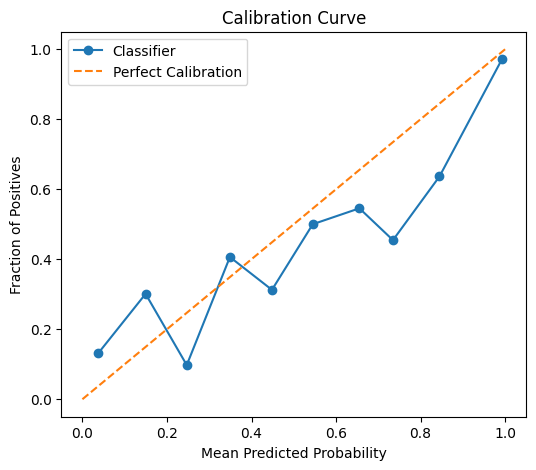

In [89]:
prob_true, prob_pred = calibration_curve(
    y_test_clf,
    prob_clf,
    n_bins=10
)

plt.figure(figsize=(6,5))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Classifier"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")

plt.title("Calibration Curve")

plt.legend()

plt.show()

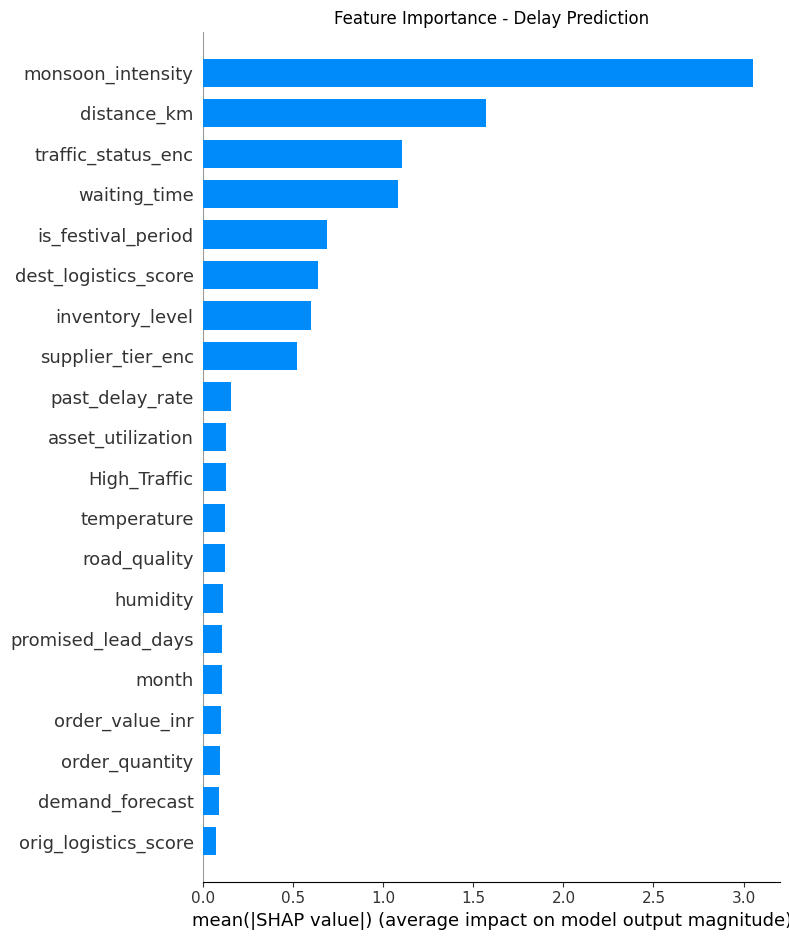

SHAP plot saved as shap_delay.png


In [90]:
explainer = shap.TreeExplainer(reg)

sample = X_train_reg.sample(
    min(500, len(X_train_reg)),
    random_state=42
)

shap_values = explainer.shap_values(sample)

plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    sample,
    feature_names=FEATURES,
    show=False,
    plot_type="bar"
)

plt.title("Feature Importance - Delay Prediction")

plt.tight_layout()

plt.savefig(
    "shap_delay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP plot saved as shap_delay.png")

In [91]:
import os
import joblib

os.makedirs("/kaggle/working/models", exist_ok=True)

joblib.dump(
    clf,
    "/kaggle/working/models/delay_classifier.pkl"
)

joblib.dump(
    reg,
    "/kaggle/working/models/delay_regressor.pkl"
)

joblib.dump(
    reg_lo,
    "/kaggle/working/models/delay_regressor_low.pkl"
)

joblib.dump(
    reg_hi,
    "/kaggle/working/models/delay_regressor_high.pkl"
)

joblib.dump(
    encoders,
    "/kaggle/working/models/label_encoders.pkl"
)

print("All models saved successfully.")

All models saved successfully.
